In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from optimization_project import modified_gauss_newton

import inspect
from optimization_project import problems as problems_module

problems = [
    cls() for name, cls in inspect.getmembers(problems_module, inspect.isclass)
    if name.endswith("Problem") and name != "Problem"
]

In [6]:
def run_scipy_with_history(problem, x0):
    history = []

    def callback(xk, *args, **kwargs):
        F = problem.F(xk)
        rss = (F**2).sum()
        history.append(rss)

    res = least_squares(
        fun=problem.F,
        jac=problem.J,
        x0=x0,
        method='trf',
        xtol=1e-8,
        ftol=1e-8,
        gtol=1e-8,
        callback=callback
    )

    return res.x, history

In [7]:
def compare_methods(problems):
    for problem in problems:
        starts = problem.get_starting_points()
        n_starts = len(starts)

        print(f"\n=== {problem.name} ===")

        fig, axes = plt.subplots(1, n_starts, figsize=(6 * n_starts, 5))
        if n_starts == 1:
            axes = [axes]

        for ax, (name, x0) in zip(axes, starts.items()):

            # --- Modified Gauss-Newton ---
            x_gn, hist_mgn = modified_gauss_newton(
                problem, x0,
                M0=1e-3, L0=1e-6, M_search=2,
                tol=1e-8, max_iter=100,
                return_history=True
            )

            # --- SciPy ---
            x_sp, hist_sp = run_scipy_with_history(problem, x0)

            # --- rysowanie na danym subplot ---
            ax.semilogy(hist_mgn, label="Modified GN")
            ax.semilogy(hist_sp, label="SciPy LM")

            ax.set_title(name)
            ax.set_xlabel("Iteration")
            ax.set_ylabel("RSS")
            ax.grid()
            ax.legend()

        fig.suptitle(f"{problem.name} – convergence comparison", fontsize=14)

        plt.tight_layout()
        plt.show()


=== DanWood ===
Modified Gauss-Newton Converged in 10 iterations.
Modified Gauss-Newton Converged in 6 iterations.


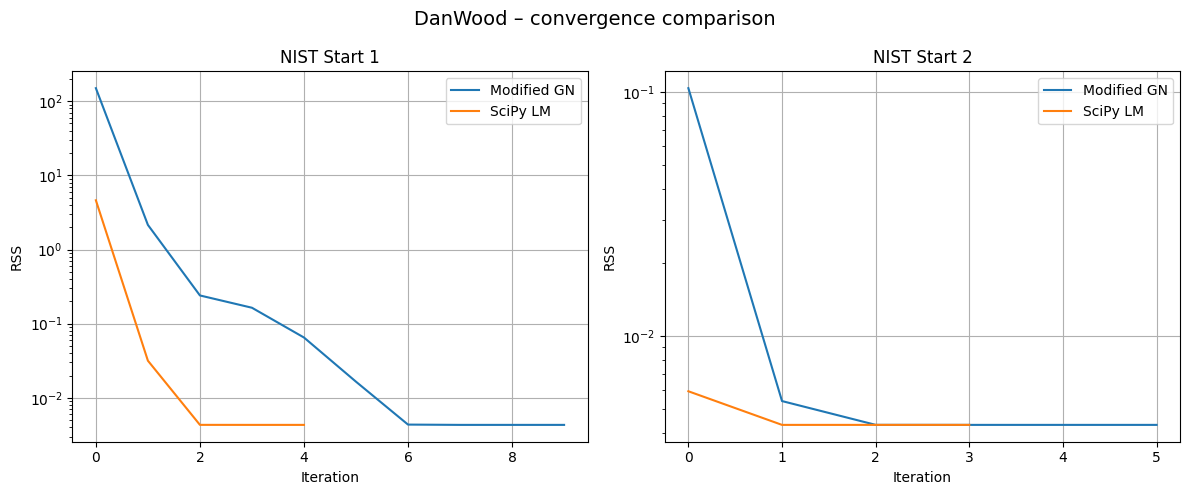


=== Eckerle4 ===
Modified Gauss-Newton Converged in 31 iterations.
Modified Gauss-Newton Converged in 9 iterations.


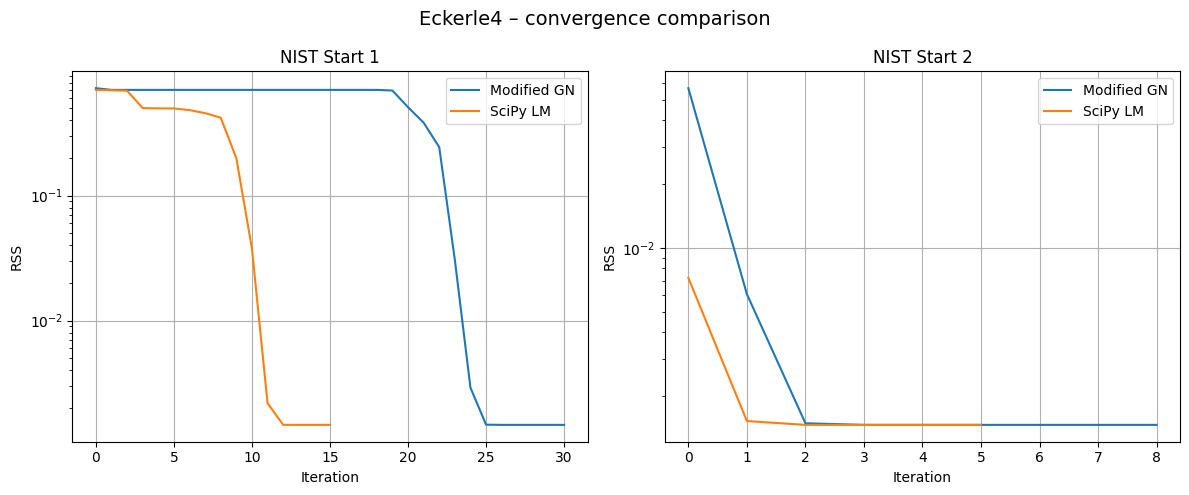


=== MGH17 ===


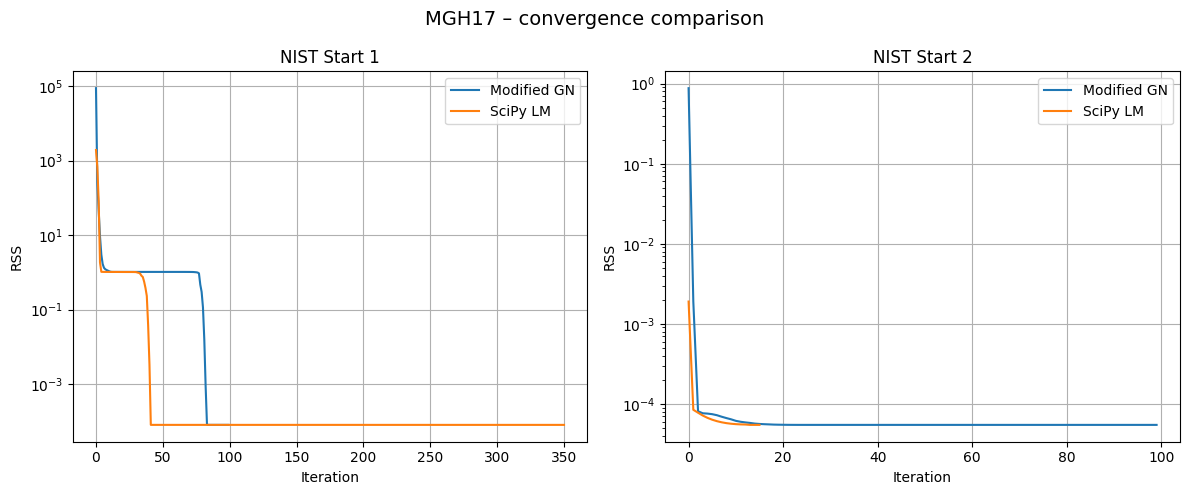


=== Roszman1 ===


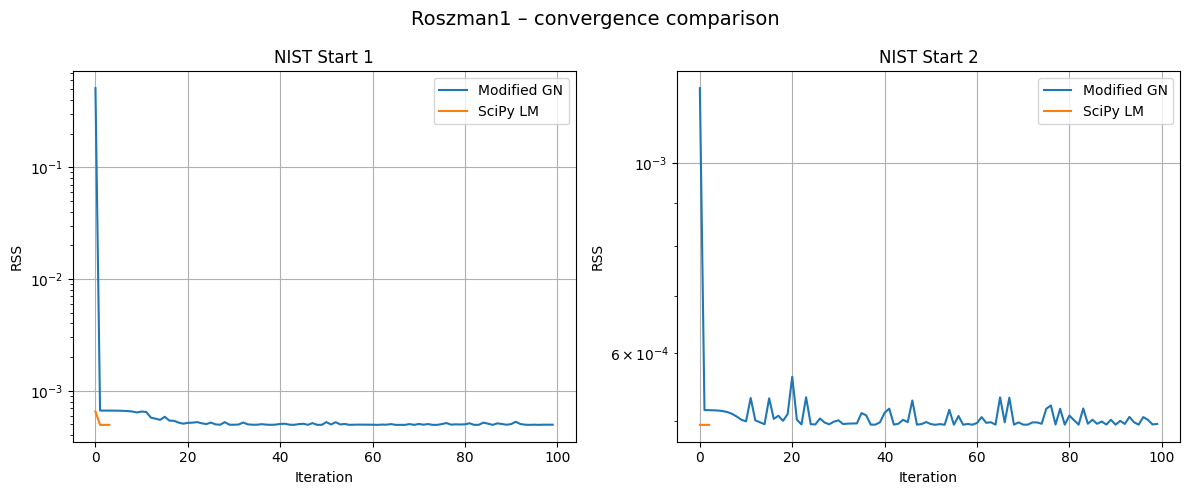


=== Thurber ===


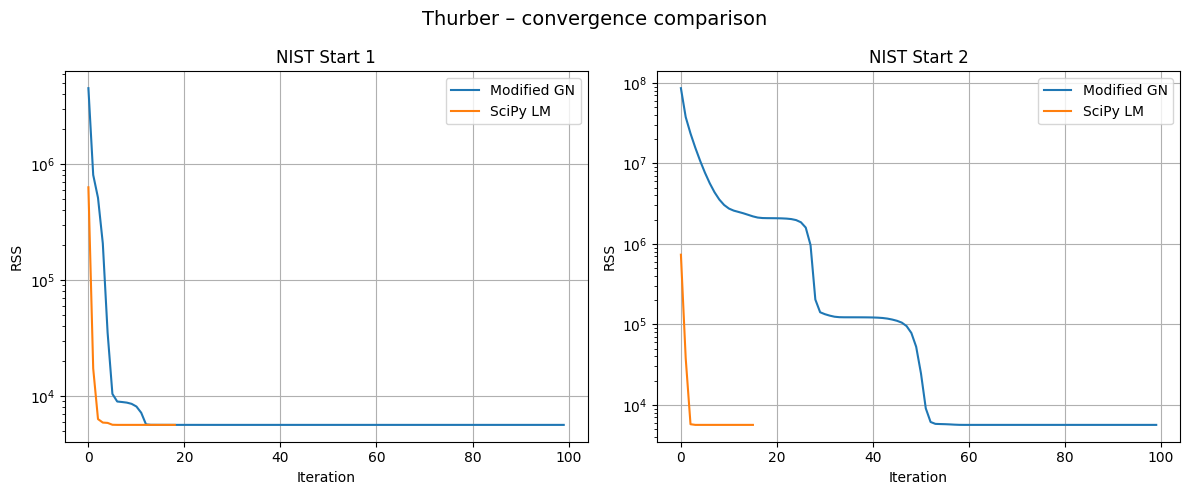

In [8]:
compare_methods(problems)